In [23]:
import matplotlib.pyplot as plt
import pyccl as ccl
import numpy as np
import corner
from IPython.display import display, Math
import seaborn as sns
import matplotlib.colors as mcolors
import getdist.plots

In [89]:
# get header from chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2(old).txt

# load header of ("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2(old).txt"
# the header is the lines that start with '#'
header = []
with open("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 'r') as f:
    # only read the top lines until it doesn't start with '#'
    for line in f:
        if line.startswith('#'):
            header.append(line.strip()[3:])
        else:
            break
    

# from header, extract the parameter names and values, which are after 'Parameter values and priors:'
parameter_values = {}
parameter_names = []
flag_params = False
for item in header:
    if flag_params:
        # split by comma, then by '='
        params = item.split(',')
        for param in params:
            name, value = param.split('=')
            name = name.strip()
            value = float(value.strip())
            parameter_values[name] = value
            parameter_names.append(name)
        flag_params = False
    if item.startswith(' Parameter values and priors:'):
        flag_params = True
        continue
    

print(parameter_names)
print(parameter_values)

cosmo_universe = ccl.Cosmology(Omega_c=parameter_values['Omega_m'] - parameter_values['Omega_b'], Omega_b=parameter_values['Omega_b'], 
                               h=parameter_values['h'], A_s=parameter_values['A_s'], n_s=parameter_values['n_s'])

f_phi_universe = parameter_values['f_phi']
Bias_distribution_fiducial = np.array([parameter_values['b1'], parameter_values['b2'], parameter_values['b3'], parameter_values['b4'], parameter_values['b5']])

['Omega_m', 'f_phi', 'A_s', 'h', 'n_s', 'Omega_b', 'b1', 'b2', 'b3', 'b4', 'b5']
{'Omega_m': 0.3137721, 'f_phi': 1.0, 'A_s': 2.056248707e-09, 'h': 0.6736, 'n_s': 0.9649, 'Omega_b': 0.0493017, 'b1': 1.562362, 'b2': 1.732963, 'b3': 1.913252, 'b4': 2.100644, 'b5': 2.29321}


In [90]:
labels = parameter_names

#["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
fiducials = [cosmo_universe["Omega_m"], f_phi_universe, cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0], Bias_distribution_fiducial[1],\
         Bias_distribution_fiducial[2],Bias_distribution_fiducial[3],\
         Bias_distribution_fiducial[4]]


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


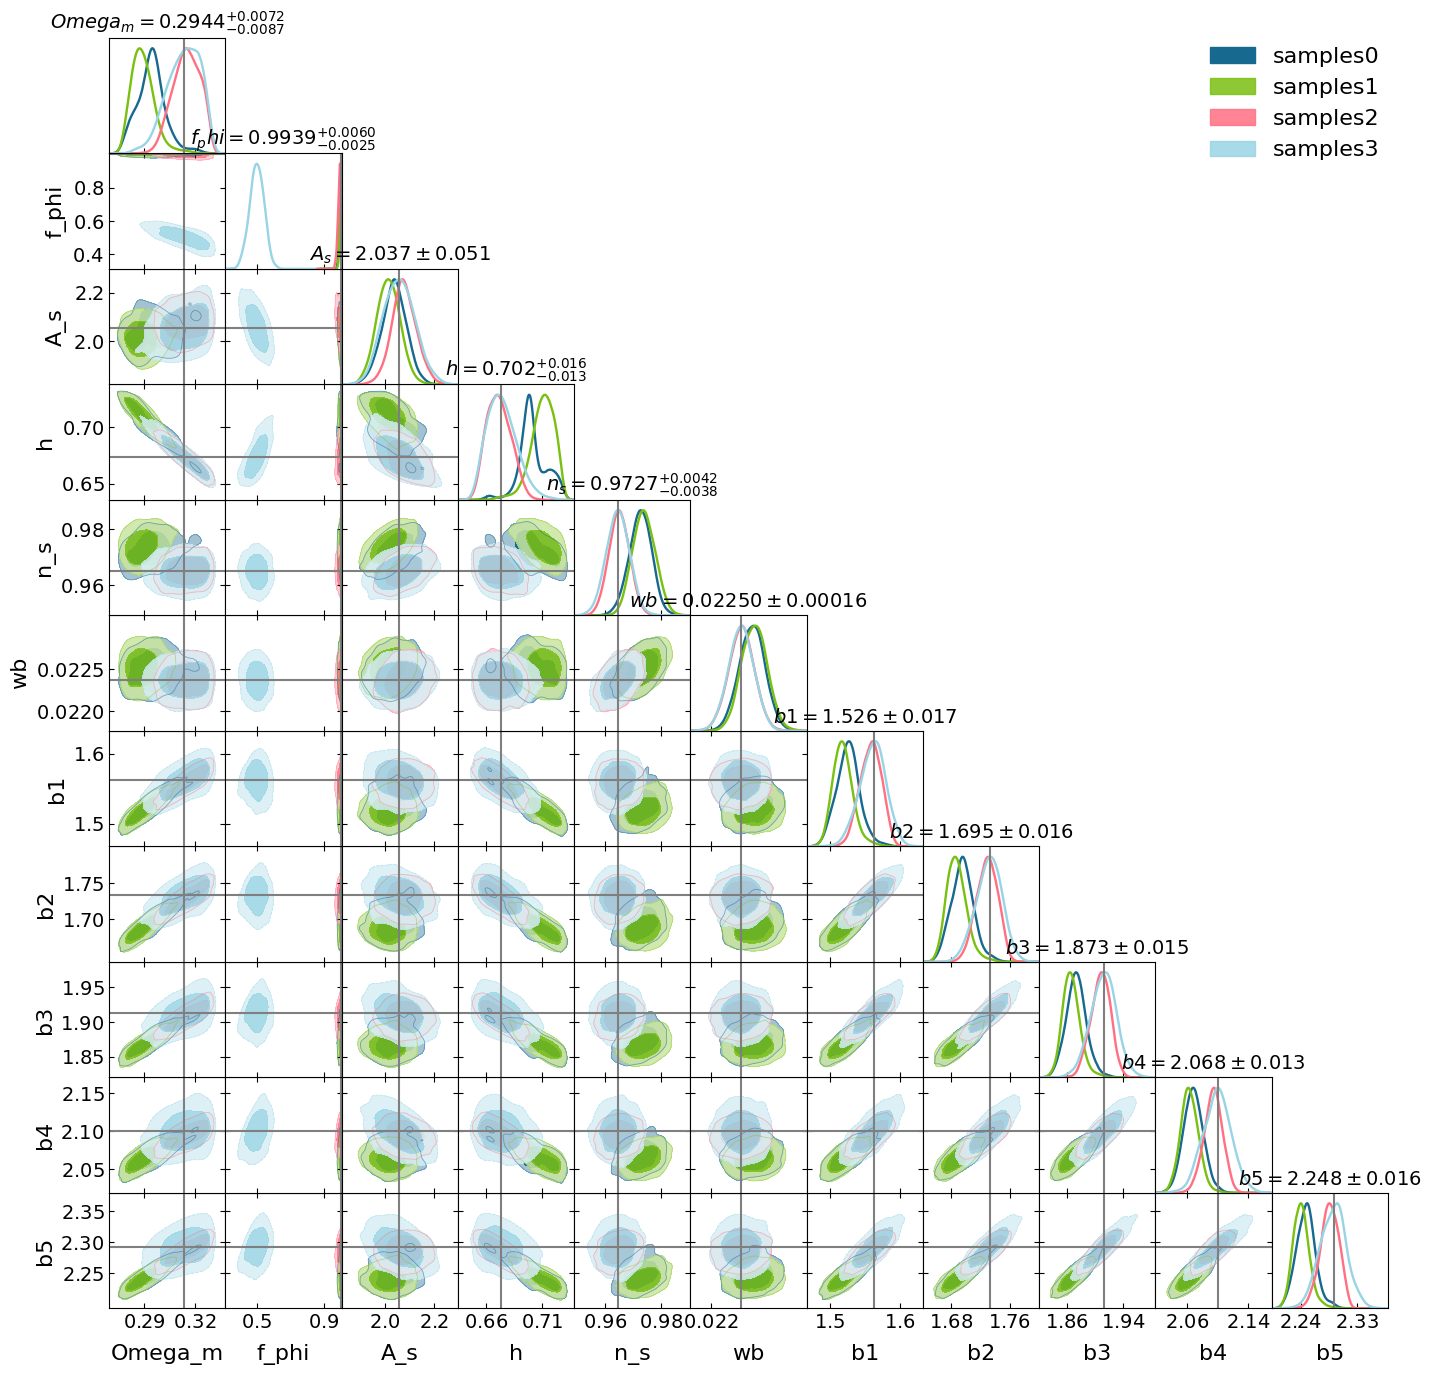

In [93]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 
                   "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2_old_noextrap.txt",
                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_ell1500_k0p2.txt",
                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.txt"]
samples = []
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    parameter_names_plots = parameter_names.copy()
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    parameter_names_plots[parameter_names.index("Omega_b")] = "wb"
    parameter_values_plots = parameter_values.copy()
    parameter_values_plots["wb"] = parameter_values["Omega_b"]*parameter_values["h"]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4   
g.settings.figure_legend_frame = False

g.triangle_plot(samples,
    parameter_names_plots,
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(parameter_names_plots)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    


In [45]:
# run short chain for log prior to sample prior space
import multiprocessing
import scipy

import yaml
from nautilus import Prior, Sampler


config_file = "/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/ini_files/config_run_ell1500_k0p2_Nbody.yaml"
# read the config file
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)


sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

with open(config['data']['params'], 'r') as f:
        params = yaml.safe_load(f)

# add additional bespoke priors if needed
def log_prior(theta_dict):
    theta = [float(theta_dict[key]) for key in ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]]
    Omega_c, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5 = theta 
    priors = params['priors']
    if not priors['Planck_prior']:
        return 0.0
    else:
        gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)
        return gauss_funct.logpdf([n_s, Omega_b*h**2])

# add standard priors
prior = Prior()
params_list = ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
for par_i in params_list:
    prior.add_parameter(par_i, dist=(params['priors'][par_i][0], params['priors'][par_i][1]))


sampler = Sampler(prior, log_prior, 
                filepath= 'priorchain_tests.hdf5', resume=config['sampler']['mcmc']['resume'], n_live=config['sampler']['mcmc']['n_live'], pool=multiprocessing.Pool(multiprocessing.cpu_count()))
sampler.run(verbose=bool(config['sampler']['mcmc']['verbose']), discard_exploration=True, n_eff=float(10000))
log_z = sampler.evidence()
points, log_w, log_l = sampler.posterior()

np.savetxt("priorchain_tests.txt", np.c_[points, log_w, log_l], footer='log_Z = {log_z}'.format(log_z=log_z))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 16     | 1        | 4        | 29744    | N/A    | 10086 | +6.11    


/tmp/ipykernel_361837/406940218.py:43: DeprecationWarning: The function 'evidence' is deprecated. Please use the property 'log_z', instead.
  log_z = sampler.evidence()


### Figure out if priors are an issue

In [44]:
#### Get Planck priors #####
# print 1/2sigma values for Omega_b and n_s from Planck prior samples

print("Planck prior 1-sigma for Omega_b:", np.sqrt(cov_prior[1,1])/cosmo_universe["h"]**2)
print("Planck prior 1-sigma for n_s:", np.sqrt(cov_prior[0,0]))
print("value of Omega_b_lower from Planck prior:", mu_prior[1]/cosmo_universe["h"]**2 - np.sqrt(cov_prior[1,1])/cosmo_universe["h"]**2)
print("values of Omega_b_fiducial from Planck prior:", mu_prior[1]/cosmo_universe["h"]**2)
print("value of Omega_b_upper from Planck prior:", mu_prior[1]/cosmo_universe["h"]**2 + np.sqrt(cov_prior[1,1])/cosmo_universe["h"]**2)
print("value of n_s_lower from Planck prior:", mu_prior[0] - np.sqrt(cov_prior[0,0]))
print("value of n_s_upper from Planck prior:", mu_prior[0] + np.sqrt(cov_prior[0,0]))
print("value of n_s_fiducial from Planck prior:", mu_prior[0])

Planck prior 1-sigma for Omega_b: 0.00035031465547806615
Planck prior 1-sigma for n_s: 0.004514538780635848
value of Omega_b_lower from Planck prior: 0.04895138534452194
values of Omega_b_fiducial from Planck prior: 0.049301700000000004
value of Omega_b_upper from Planck prior: 0.04965201465547807
value of n_s_lower from Planck prior: 0.9603854612193641
value of n_s_upper from Planck prior: 0.9694145387806359
value of n_s_fiducial from Planck prior: 0.9649


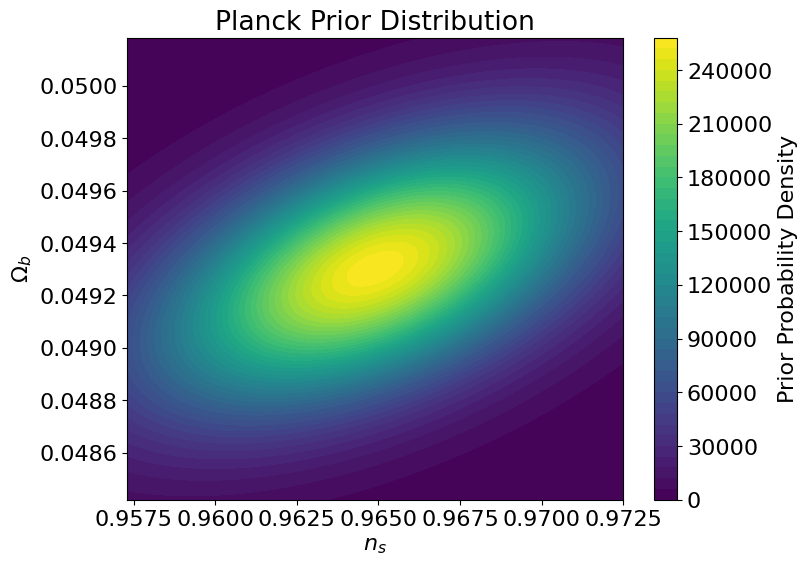

In [39]:
# plot prior distribution for n_s and Omega_b*h^2
import scipy


n_s_range = np.linspace(cosmo_universe['n_s']-0.0038*2, cosmo_universe['n_s']+0.0038*2, 100)
Omega_b_h2_range = np.linspace(cosmo_universe['Omega_b']*cosmo_universe["h"]**2-0.0002*2, cosmo_universe['Omega_b']*cosmo_universe["h"]**2+0.0002*2, 100)
n_s_grid, Omega_b_h2_grid = np.meshgrid(n_s_range, Omega_b_h2_range)
pos = np.dstack((n_s_grid, Omega_b_h2_grid))

prior_val = np.zeros_like(n_s_grid)
for i in range(n_s_grid.shape[0]):
    for j in range(n_s_grid.shape[1]):
        prior_val[i,j] = log_prior({"Omega_m": cosmo_universe["Omega_m"], "f_phi": f_phi_universe, "1e9As": cosmo_universe["A_s"]*1e9, "h": cosmo_universe["h"], "ns": n_s_grid[i,j], "Omega_b": Omega_b_h2_grid[i,j]/cosmo_universe["h"]**2, "b1": Bias_distribution_fiducial[0], "b2": Bias_distribution_fiducial[1], "b3": Bias_distribution_fiducial[2], "b4": Bias_distribution_fiducial[3], "b5": Bias_distribution_fiducial[4]})

plt.figure(figsize=(8,6))
plt.contourf(n_s_grid, Omega_b_h2_grid/cosmo_universe["h"]**2, np.exp(prior_val), levels=50, cmap='viridis')
plt.colorbar(label='Prior Probability Density')
plt.xlabel(r'$n_s$')
plt.ylabel(r'$\Omega_b$')
plt.title('Planck Prior Distribution')
plt.show()




In [56]:
# plot from emcee file
import emcee
# 
filename = "mcmcmcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.h5"

while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
raw_chain = reader.get_chain()#
print(f"Current raw chain shape: {raw_chain.shape}")

tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))

Number of steps completed: 110
Current raw chain shape: (110, 80, 11)
Current iteration: 110
Max 100 x Tau/N: 13.768683727518791


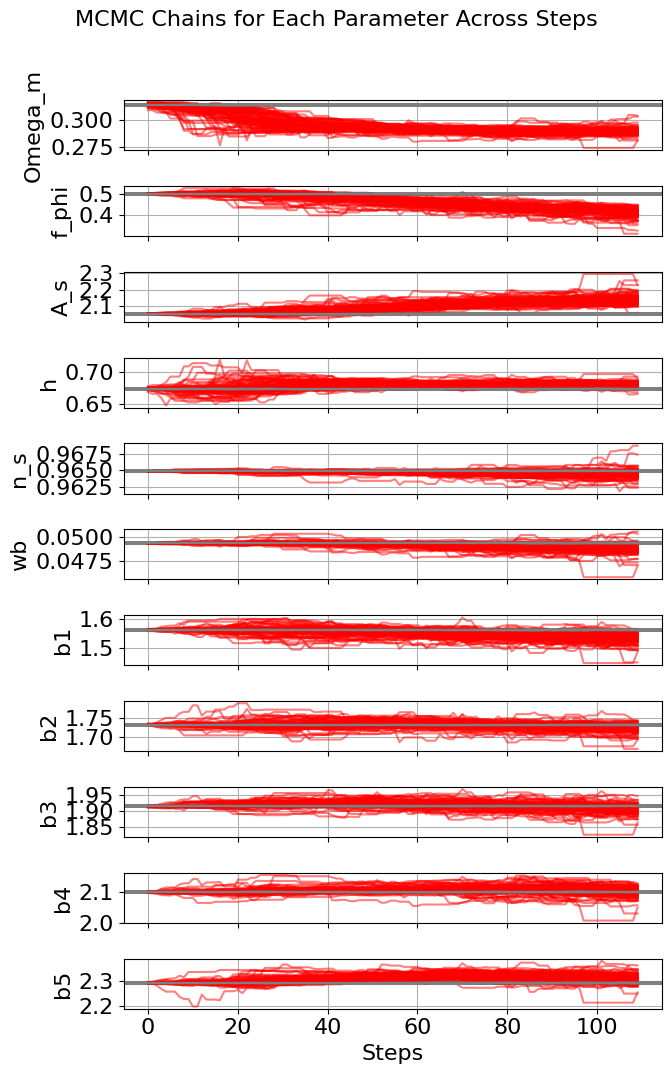

In [61]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.
n_steps, n_walkers, n_params = raw_chain.shape

# Create a figure with subplots, one for each parameter
fig, axes = plt.subplots(n_params, figsize=(7, n_params), sharex=True)

fiducials = [parameter_values[name] for name in parameter_names]
# set A_s fiducial to 1e9 times the value in parameter_values, since we are plotting 1e9As
fiducials[parameter_names.index("A_s")] = parameter_values["A_s"]*1e9
# set f_phi fiducial to 0.5 
fiducials[parameter_names.index("f_phi")] = 0.5
# Iterate over each parameter and plot its evolution
for i in range(n_params):
    ax = axes[i]
    for j in range(n_walkers):
        ax.plot(raw_chain[:, j, i], alpha=0.5, color="r")  # Plot for each walker
        # plot the fiducial parameter values
        ax.axhline(fiducials[i], lw=1.5, color='tab:gray')

    ax.set_ylabel(labels[i])
    ax.grid()

# Add a label for the shared x-axis (steps/iterations)
axes[-1].set_xlabel("Steps")

# Set the overall title and adjust layout
plt.suptitle("MCMC Chains for Each Parameter Across Steps", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()